In [ ]:
from google.colab import files
uploaded = files.upload()

Saving StudentsPerformance.csv to StudentsPerformance (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [ ]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [ ]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

In [ ]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
df[['math_score',
    'reading_score',
    'writing_score']].mean()

,0
math_score,66.089
reading_score,69.169
writing_score,68.054


In [ ]:
gender_analysis = df.groupby('gender')[[
    'math_score',
    'reading_score',
    'writing_score'
]].mean()

gender_analysis

,math_score,reading_score,writing_score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


In [ ]:
prep_analysis = df.groupby(
    'test_preparation_course'
)[[
    'math_score',
    'reading_score',
    'writing_score'
]].mean()

prep_analysis

,math_score,reading_score,writing_score
test_preparation_course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


In [ ]:
education_analysis = df.groupby(
    'parental_level_of_education'
)[[
    'math_score',
    'reading_score',
    'writing_score'
]].mean()

education_analysis

,math_score,reading_score,writing_score
parental_level_of_education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


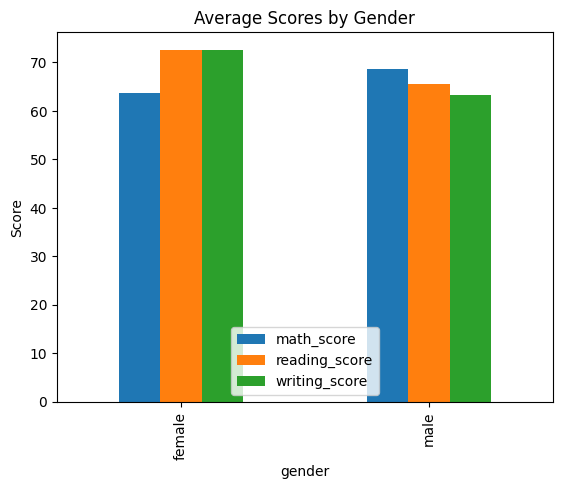

In [ ]:
gender_analysis.plot(kind='bar')

plt.title('Average Scores by Gender')
plt.ylabel('Score')
plt.show()

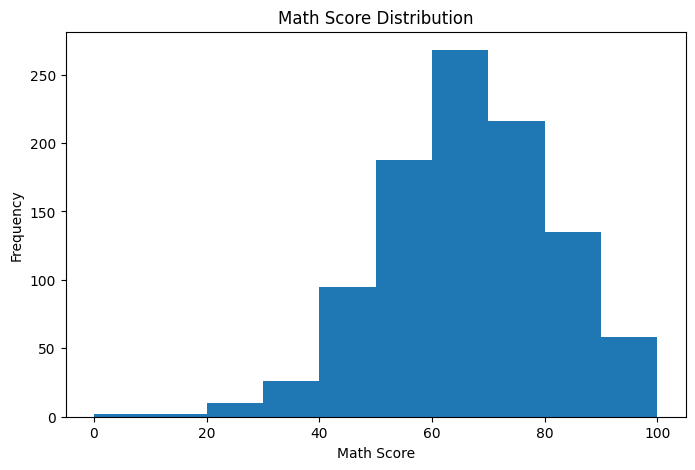

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['math_score'], bins=10)

plt.title('Math Score Distribution')
plt.xlabel('Math Score')
plt.ylabel('Frequency')

plt.show()

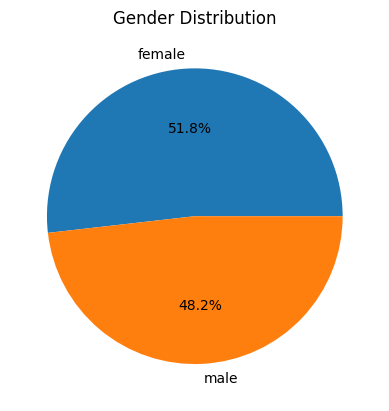

In [ ]:
df['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Gender Distribution')
plt.ylabel('')

plt.show()

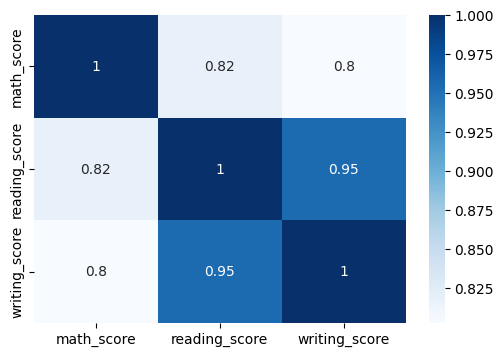

In [ ]:
corr = df[['math_score',
           'reading_score',
           'writing_score']].corr()

plt.figure(figsize=(6,4))

sns.heatmap(corr,
            annot=True,
            cmap='Blues')

plt.show()